In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec

from scipy.optimize import minimize_scalar

from AbelianCT_Potential import Abelian_Model as AbelianCT_Model
from AbelianCT_Potential import Abelian_Model

## Define the Model

In [3]:
# Parameters: strong FOPT regime (large g/sqrt(lam) ratio)
lam, mu, g = 0.05, 50.0, 1

model = AbelianCT_Model(lam, mu, g)

# Analytic expectations
v_tree  = mu / np.sqrt(lam)
mh_tree = np.sqrt(2.0) * mu
mA_tree = g * v_tree
print(f"Tree-level vev :  v  = {v_tree:.3f} GeV")
print(f"Tree-level Higgs: mh = {mh_tree:.3f} GeV")
print(f"Tree-level gauge: mA = {mA_tree:.3f} GeV")

# Numerical vev from Vtot(T=0)
T_eps = 1e-6  # numerically zero, avoids division by T=0

res = minimize_scalar(
    lambda phi: model.Vtot(np.array([[phi]]), T_eps).item(),
    bounds=(50, 350),
    method='bounded'
)
v_num = res.x
print(f"Numerical vev (Vtot, T=0): {v_num:.3f} GeV")
print(f"CW shift: {abs(v_num - v_tree)/v_tree * 100:.3f}%")

Tree-level vev :  v  = 223.607 GeV
Tree-level Higgs: mh = 70.711 GeV
Tree-level gauge: mA = 223.607 GeV
Numerical vev (Vtot, T=0): 223.607 GeV
CW shift: 0.000%


## Coleman Weinberg ($T=0$)

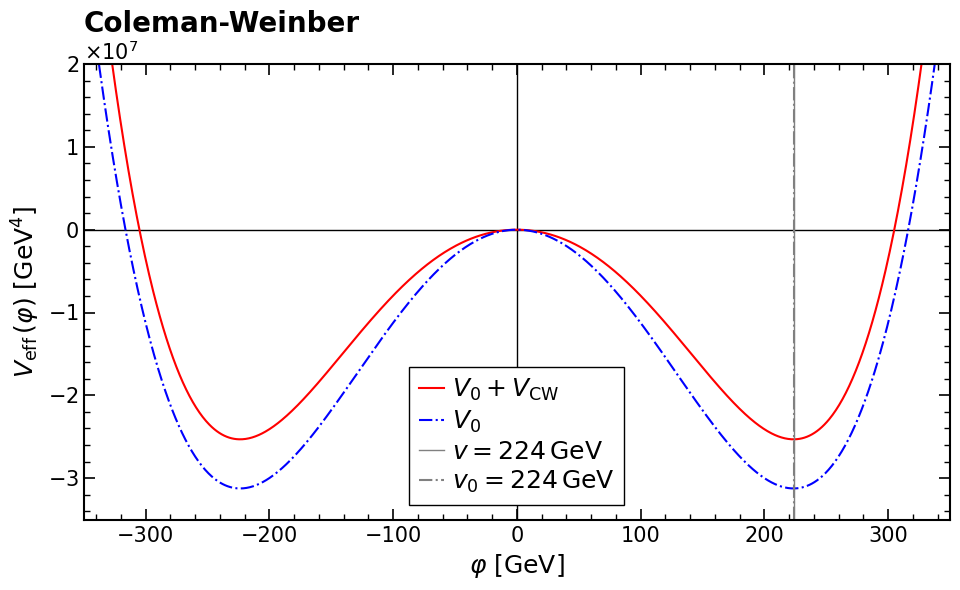

In [7]:
phi_vals = np.linspace(-500, 500, 1500)
X        = phi_vals[:, np.newaxis] 

V_tree   = model.V0(X)
V_tot_0  = model.Vtot(X, 0.0)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

ax.plot(phi_vals, V_tot_0-model.Vtot(np.array([[0.0]]), 0.0), label=r'$V_0 + V_\mathrm{CW}$', color='r', lw=1.5, ls='-')
ax.plot(phi_vals, V_tree-model.V0(np.array([[0.0]])), label=r'$V_0$', color='b', lw=1.5, ls='-.')

ax.axvline(v_num, label=rf'$v={float(np.squeeze(v_num)):.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.0, ls='-', alpha=1)
ax.axvline(v_tree, label=rf'$v_0={v_tree:.0f} \, \mathrm{{GeV}}$', color='gray', lw=1.5, ls='-.', alpha=1)

ax.set_xlim(-350, 350)
ax.set_ylim(-3.5e7,2e7)

ax.set_xlabel(r'$\varphi$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis='x', which='major', pad=5)

plt.legend(fontsize=18, frameon=True, fancybox=False, loc = "lower center", bbox_to_anchor=(0.5, 0.005),
               ncol = 1, edgecolor="black", framealpha=1, labelspacing=0.2, handletextpad=0.3, handlelength=1, columnspacing=1)

plt.title(r"Coleman-Weinber", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("figures\AbelianCT_CW.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Thermal Evolution

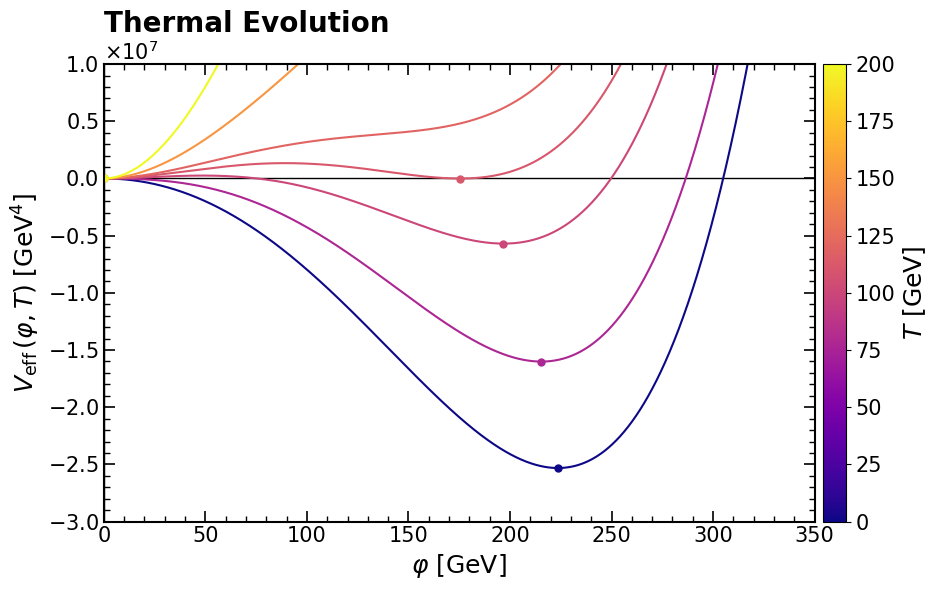

In [9]:
T_vals   = np.array([0, 77, 100, 111, 120, 150, 200])
phi_vals = np.linspace(-1,400,2000)
X        = phi_vals[:, np.newaxis]

# Colormap
cmap  = plt.cm.plasma
norm  = Normalize(vmin=0, vmax=T_vals.max())
sm    = ScalarMappable(cmap=cmap, norm=norm)

fig, ax = plt.subplots(figsize=(9.7, 6))

ax.axhline(0, color='k', lw=1, ls='-')
ax.axvline(0, color='k', lw=1, ls='-')

for T in T_vals:
    V = model.Vtot(X, T)
    V_norm = V - model.Vtot(np.array([[0.0]]), T)
    color = cmap(norm(T))
    label = r'$T = 0$' if T < 1 else rf'$T = {T:.0f}$ GeV'
    ax.plot(phi_vals, V_norm, color=color, lw=1.5, label=label)

    # Mark the minimum of the broken phase
    mask = phi_vals > 0          # Impose Positive vev
    idx  = np.argmin(V[mask])
    phi_min = phi_vals[mask][idx]
    V_min   = V[mask][idx]
    ax.plot(phi_min, V_min-model.Vtot(np.array([[0.0]]), T), 'o', color=color, ms=5)

ax.set_xlim(0, 350)
ax.set_ylim(-3e7,1e7)

ax.set_xlabel(r'$\varphi$ $\left[\mathrm{GeV}\right]$', fontsize=18)
ax.set_ylabel(r'$V_\mathrm{eff}\,(\varphi, T)$ $\left[\mathrm{GeV^4}\right]$', fontsize=18)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(-2, 2))
ax.yaxis.get_offset_text().set_fontsize(15)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Configure ticks
ax.tick_params(axis='both', which='major', direction='in', length=8, width=1.2, labelsize=15, top=True, right=True)
ax.tick_params(axis='both', which='minor', direction='in', length=4, width=1, labelsize=15, top=True, right=True)
ax.minorticks_on()

cbar = fig.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label(r'$T\ [\mathrm{GeV}]$', fontsize=18)
cbar.ax.tick_params(labelsize=15)


#annotation = (rf"$T_c   = 132.85 \, \mathrm{{GeV}}$"  "\n"rf"$\xi_c = 1.36$")
#ax.text(0.05, 0.2, annotation,transform=ax.transAxes,fontsize=18,verticalalignment='top',horizontalalignment='left')

plt.title(r"Thermal Evolution", loc='left', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig("figures\AbelianCT_Thermal.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Phase Transition

In [ ]:
model.Tmax = 200

In [29]:
trans = model.calcTcTrans()
print(trans)
Tc   = trans[0]['Tcrit']
high = trans[0]['high_vev']
low  = trans[0]['low_vev']
xi_c = abs(low[0] - high[0]) / Tc
print(f"Tc = {Tc:.2f} GeV  |  xi_c = {xi_c:.2f}")

[{'Tcrit': 111.00877873407462, 'high_vev': array([0.0028279]), 'high_phase': 1, 'low_vev': array([175.34883855]), 'low_phase': 0, 'trantype': 1, 'Delta_rho': 57223632.90105611}]
Tc = 111.01 GeV  |  xi_c = 1.58


In [11]:
model.Tmax = 200
model.findAllTransitions()
print()
print("=======================================================")
print("The model has", len(model.TnTrans), "transition(s)")
print("=======================================================")

Tracing phase starting at x = [223.60679787] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
..........................................................................................................................................
Tracing phase starting at x = [-3.11523438e-06] ; t = 116.85762646791667
Tracing minimum down
traceMinimum t0 = 116.858
...............................
Tracing minimum up
traceMinimum t0 = 116.858
....
Tunneling from phase 1 to phase 0 at T=83.71018
high_vev = [0.00329902]
low_vev = [211.85187186]


C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:337: RuntimeWarning: overflow encountered in scalar multiply
  beta_r = beta*r
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:421: RuntimeWarning: overflow encountered in scalar multiply
  r *= 10
C:\Users\Usuario\anaconda3\Lib\site-packages\cosmoTransitions\tunneling1D.py:337: RuntimeWarning: overflow encountered in scalar multiply
  beta_r = beta*r


ValueError: The function value at x=2.365601445453237e+307 is NaN; solver cannot continue.

### Critical Temperature $T_C$

In [17]:
# Find T_c & Transition strength
for i, trans in enumerate(model.TnTrans):
    Tc   = trans["crit_trans"]['Tcrit']
    high = trans["crit_trans"]['high_vev']
    low  = trans["crit_trans"]['low_vev']
    xi_c = abs(low[0] - high[0]) / Tc
    print(f"Transition {i}:  Tc = {Tc:.2f} GeV  |  xi_c = {xi_c:.2f}")

Transition 0:  Tc = 132.85 GeV  |  xi_c = 1.36


In [13]:
model.getPhases()

Tracing phase starting at x = [223.60679787] ; t = 0.0
Tracing minimum up
traceMinimum t0 = 0
..........................................................................................................................................
Tracing phase starting at x = [-3.11523438e-06] ; t = 116.85762646791667
Tracing minimum down
traceMinimum t0 = 116.858
...............................
Tracing minimum up
traceMinimum t0 = 116.858
....


{0: Phase(key=0, X=[[223.6], ..., [138.9]], T=[0, ..., 116.7], dXdT=[[-0], ..., [-71.64]],
 1: Phase(key=1, X=[[0.00332], ..., [0.0006843]], T=[83.71, ..., 200], dXdT=[[-10.13], ..., [-1.591e-05]]}

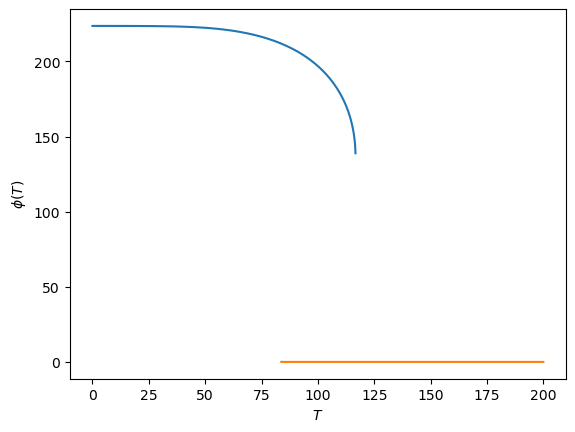

In [15]:
model.plotPhasesPhi()